In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import tensorflow as tf
import keras
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from keras.models import Model
from keras.layers import Input, Conv2D, LeakyReLU, BatchNormalization, MaxPool2D, Conv2DTranspose, concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
# Görüntülerin ve maskelerin bulunduğu dizinin yolu
IMAGE_PATH = 'C:/Users/iavcc/Desktop/Online Dersler/Görüntü İşleme/data2/kaggle_3m'

# Görüntülerin ve maskelerin yeniden boyutlandırılacağı boyutlar (genişlik, yükseklik)
IMAGE_SIZE = (256, 256)

# Eğitim için kullanılacak epoch sayısı (veri setinin eğitim sırasında kaç kez tam olarak kullanılacağı)
EPOCHS = 60

# Eğitim sırasında her bir iterasyonda kullanılacak veri parçası (batch) boyutu
BATCH_SIZE = 45


In [3]:
# Her bir görüntü ve maskenin yolunu tutmak için bir liste
paths = []

# IMAGE_PATH dizinindeki alt dizinleri tarar
for dirname in os.listdir(IMAGE_PATH):
    # Eğer alt dizin ise işlemi sürdür
    if os.path.isdir(os.path.join(IMAGE_PATH, dirname)):
        
        # Alt dizindeki dosyaları tarar
        for filename in os.listdir(os.path.join(IMAGE_PATH, dirname)):
            # Sadece '.tif' formatındaki dosyalar 'paths' listesine eklenir
            if filename.endswith('.tif'):
                paths.append(IMAGE_PATH + '/' + dirname + '/' + filename)

# 'paths' listesinin uzunluğunu ve her 5. dosya yolunu göstermek için (ilk 20 eleman)
len(paths), paths[:20:5]


(7858,
 ['C:/Users/iavcc/Desktop/Online Dersler/Görüntü İşleme/data2/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1.tif',
  'C:/Users/iavcc/Desktop/Online Dersler/Görüntü İşleme/data2/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_12.tif',
  'C:/Users/iavcc/Desktop/Online Dersler/Görüntü İşleme/data2/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_14_mask.tif',
  'C:/Users/iavcc/Desktop/Online Dersler/Görüntü İşleme/data2/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_17.tif'])

In [4]:
# 'paths' listesinden, görüntüler ve maskeler ayrılarak, ID'lerin ve tanıların (diagnoses) çıkarılmasıyla bir dataframe oluşturma işlevi
def data_frame(data):
    # 'mask.tif' ile bitmeyen yolları (görüntüleri) tutuyor
    images = list(filter(lambda x: not x.endswith('mask.tif'), data))
    # Her MRI'yi numaralarına göre sıralıyor
    images.sort(key=lambda x: int(x.rsplit('_', 3)[-1][:-4]))
    # Hasta ID'lerine göre sıralama (her hastanın birden fazla MR görüntüsü var)
    images.sort(key=lambda x: int(x.rsplit('_', 3)[-2]))
    
    # Görüntü ID'lerini tutuyor
    IDs = list(map(lambda x: x.rsplit('/', 3)[-1][:-4], images))

    # 'mask.tif' ile biten yolları (maskeleri) tutuyor
    masks = list(filter(lambda x: x.endswith('mask.tif'), data))
    # Her MRI maskesini numaralarına göre sıralıyor
    masks.sort(key=lambda x: int(x.rsplit('_', 3)[-2]))
    # Hasta ID'lerine göre sıralama (her hastanın birden fazla maskesi var)
    masks.sort(key=lambda x: int(x.rsplit('_', 3)[-3]))

    # Görüntüleri açıyor
    pixels = lambda x: Image.open(x)
    # Görüntüdeki en büyük piksel değerini seçiyor
    largest_pixel = lambda y: np.max(pixels(y))
    # Maskenin anormallik içerip içermediğini belirliyor (1 = anormallik var, 0 = anormallik yok)
    # Negatif bir görüntünün maskesi tamamen siyah bir görüntüdür
    diagnotic_function = lambda z: 1 if largest_pixel(z) > 0 else 0
    # Her görüntüye karşılık gelen tanıları (diagnoses) tutuyor
    diagnoses = list(map(lambda x: diagnotic_function(x), masks))

    # Bir dataframe oluşturuyor
    DataFrame = pd.DataFrame({'ID': IDs, 'Image': images, 'Mask': masks, 'Diagnosis': diagnoses})
    
    # İndeksleri eğitim (train), test ve doğrulama (validation) olarak bölüyor
    train_index, val_index = train_test_split(DataFrame.index.values.tolist(), test_size=0.19, random_state=42)
    val_index, test_index = train_test_split(val_index, test_size=0.12, random_state=42)
    
    # Eğitim, test ve doğrulama veri kümeleri oluşturuyor
    train_df, val_df, test_df = DataFrame.iloc[train_index], DataFrame.iloc[val_index], DataFrame.iloc[test_index]
    
    return train_df, val_df, test_df
    
# Veri kümelerini oluşturuyor
train_df, val_df, test_df = data_frame(paths)

# Eğitim, doğrulama ve test veri kümelerinin boyutlarını yazdırıyor
print(len(train_df), len(val_df), len(test_df))

# Eğitim veri kümesinin ilk birkaç satırını gösteriyor
train_df.head()


3182 657 90


,ID,Image,Mask,Diagnosis
812,TCGA_DU_7302_19911203_33,C:/Users/iavcc/Desktop/Online Dersler/Görüntü ...,C:/Users/iavcc/Desktop/Online Dersler/Görüntü ...,0
1550,TCGA_HT_7602_19951103_17,C:/Users/iavcc/Desktop/Online Dersler/Görüntü ...,C:/Users/iavcc/Desktop/Online Dersler/Görüntü ...,0
2228,TCGA_DU_A5TR_19970726_31,C:/Users/iavcc/Desktop/Online Dersler/Görüntü ...,C:/Users/iavcc/Desktop/Online Dersler/Görüntü ...,0
1108,TCGA_DU_5872_19950223_26,C:/Users/iavcc/Desktop/Online Dersler/Görüntü ...,C:/Users/iavcc/Desktop/Online Dersler/Görüntü ...,0
3728,TCGA_FG_7643_20021104_17,C:/Users/iavcc/Desktop/Online Dersler/Görüntü ...,C:/Users/iavcc/Desktop/Online Dersler/Görüntü ...,0


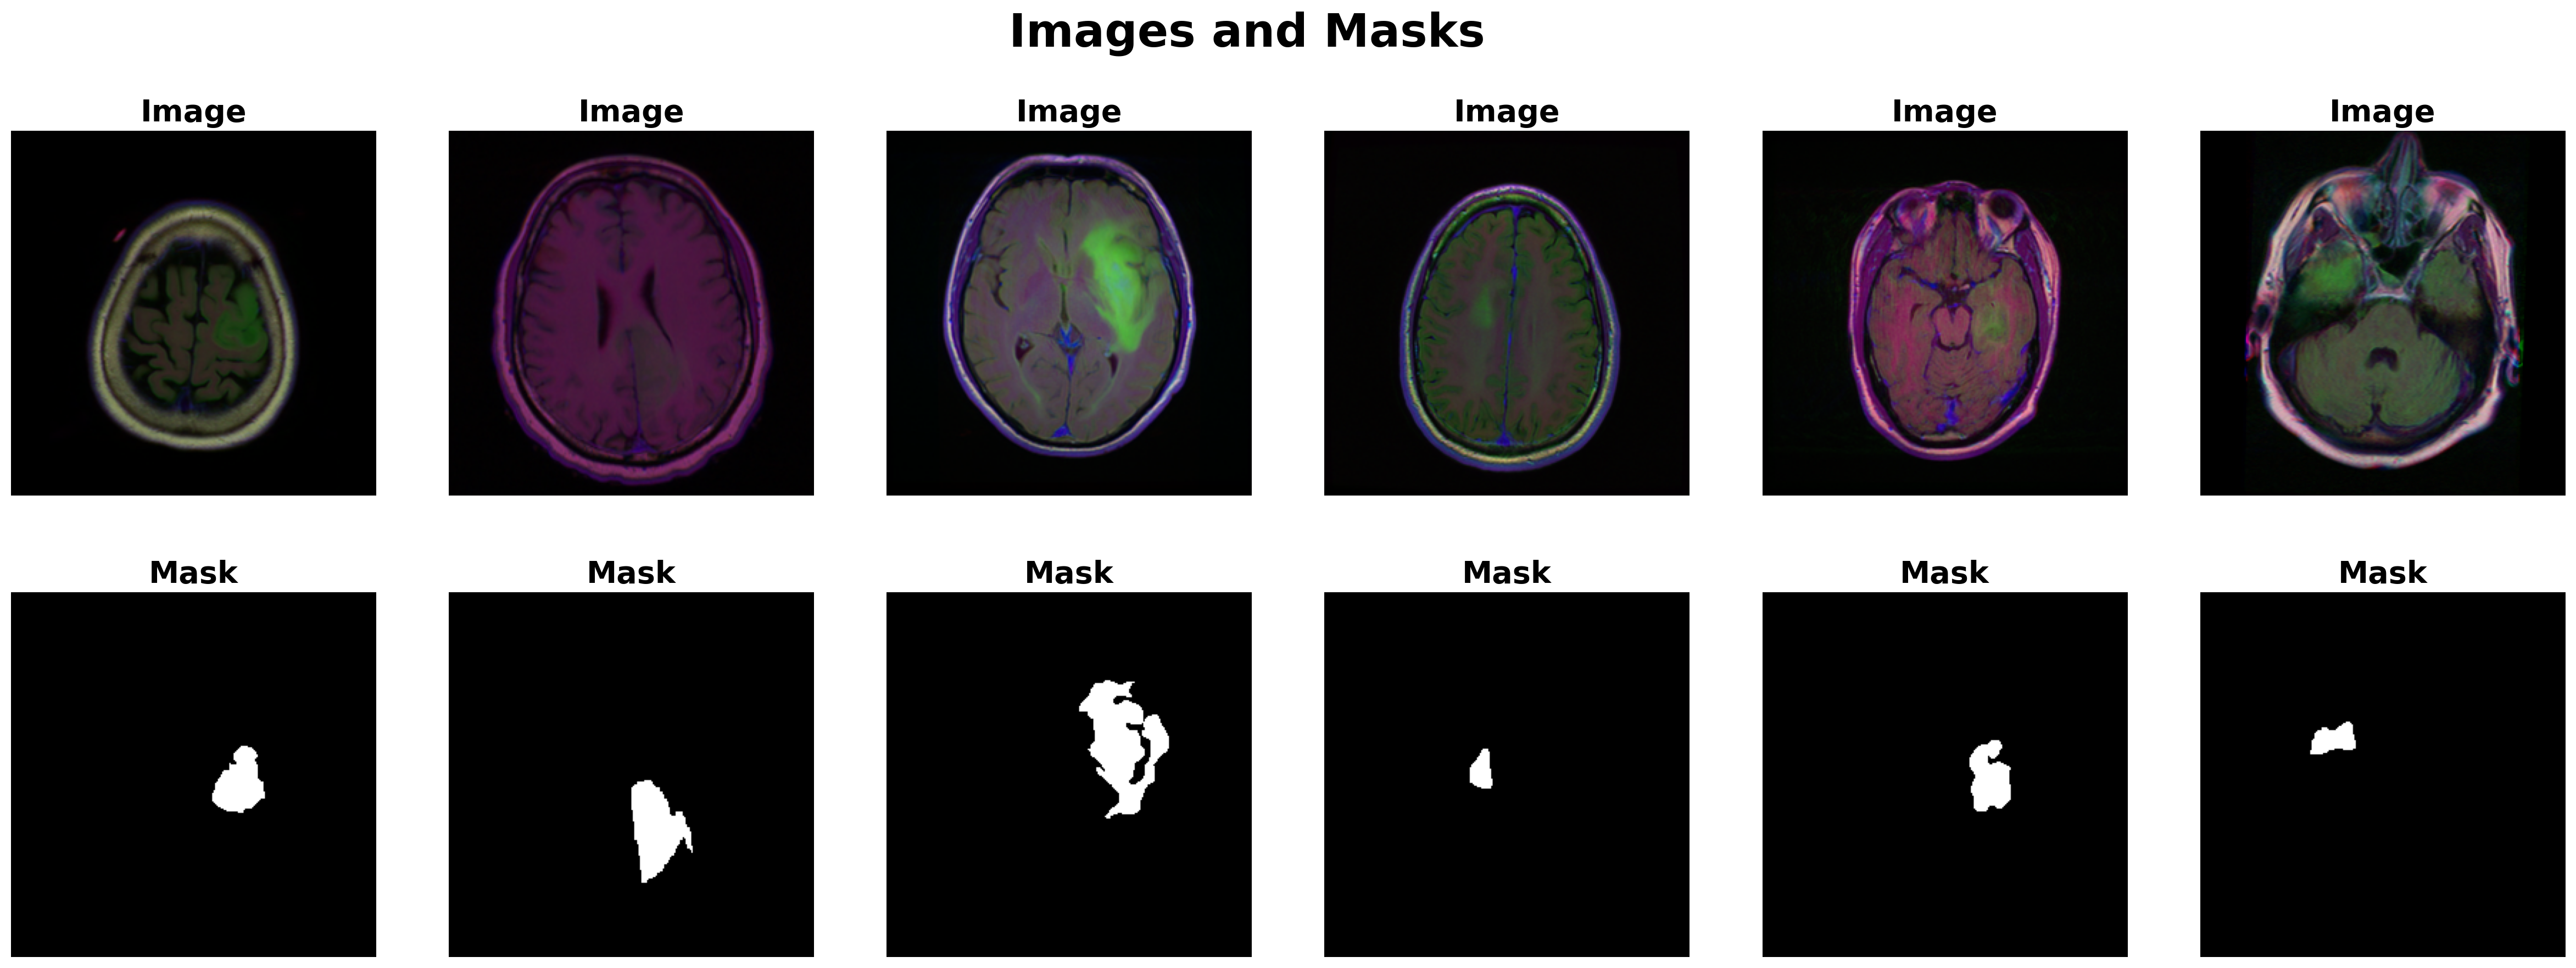

In [5]:
# Görüntüleri, maskeleri ve tahminleri (varsa) yan yana çizmek için bir fonksiyon
def plot_images_and_masks(images, masks, predictions=None, IoU_list=None):
    # Kaç adet görüntü ve maske çizileceğini belirliyor
    num_samples = len(images)
    # Tahmin dizisi fonksiyona verilmiş mi kontrol ediyor, yoksa 2 satır, tahminler varsa 3 satır olacak
    num_rows = 2 if type(predictions) == type(None) else 3
    
    # Şekli tanımlıyor (num_samples görüntü ve belirlenen satır sayısı kadar)
    fig, axes = plt.subplots(num_rows, num_samples,
                             figsize=(num_samples*5, num_samples+(num_rows*2)), dpi=200)
    
    for i in range(num_samples):
        # Görüntüyü çiziyor
        axes[0, i].imshow(Image.open(images[i]), cmap='gray')  # Görüntüyü gri tonlamada göster
        axes[0, i].set_title('Image', fontsize=20, fontweight='bold')  # Başlığı ayarla
        axes[0, i].axis('off')  # Eksenleri kapat
        
        # Maskeyi çiziyor
        axes[1, i].imshow(Image.open(masks[i]), cmap='gray')  # Maskeyi gri tonlamada göster
        axes[1, i].set_title('Mask', fontsize=20, fontweight='bold')  # Başlığı ayarla
        axes[1, i].axis('off')  # Eksenleri kapat
        
        # Tahmin verildiyse tahmini çiziyor
        if type(predictions) != type(None):
            axes[2, i].imshow(predictions[i], cmap='gray')  # Tahmin maskesini gri tonlamada göster
            # Tahminin başlığını çiziyor, IoU değerini de ekliyor
            axes[2, i].set_title(f'Prediction | IoU: {round(float(IoU_list[i]), 3)}',
                                 fontsize=19, fontweight='bold')
            axes[2, i].axis('off')  # Eksenleri kapat
             
    # Genel başlık ekliyor
    plt.suptitle('Images and Masks', fontsize=30, fontweight='bold')
    
    # Şekli gösteriyor
    plt.show()

# Eğitim veri setinde tanısı pozitif olan ilk 6 görüntüyü ve maskelerini çizdiriyor
plot_images_and_masks(train_df[train_df['Diagnosis'] == 1]['Image'].values[:6],
                      train_df[train_df['Diagnosis'] == 1]['Mask'].values[:6])


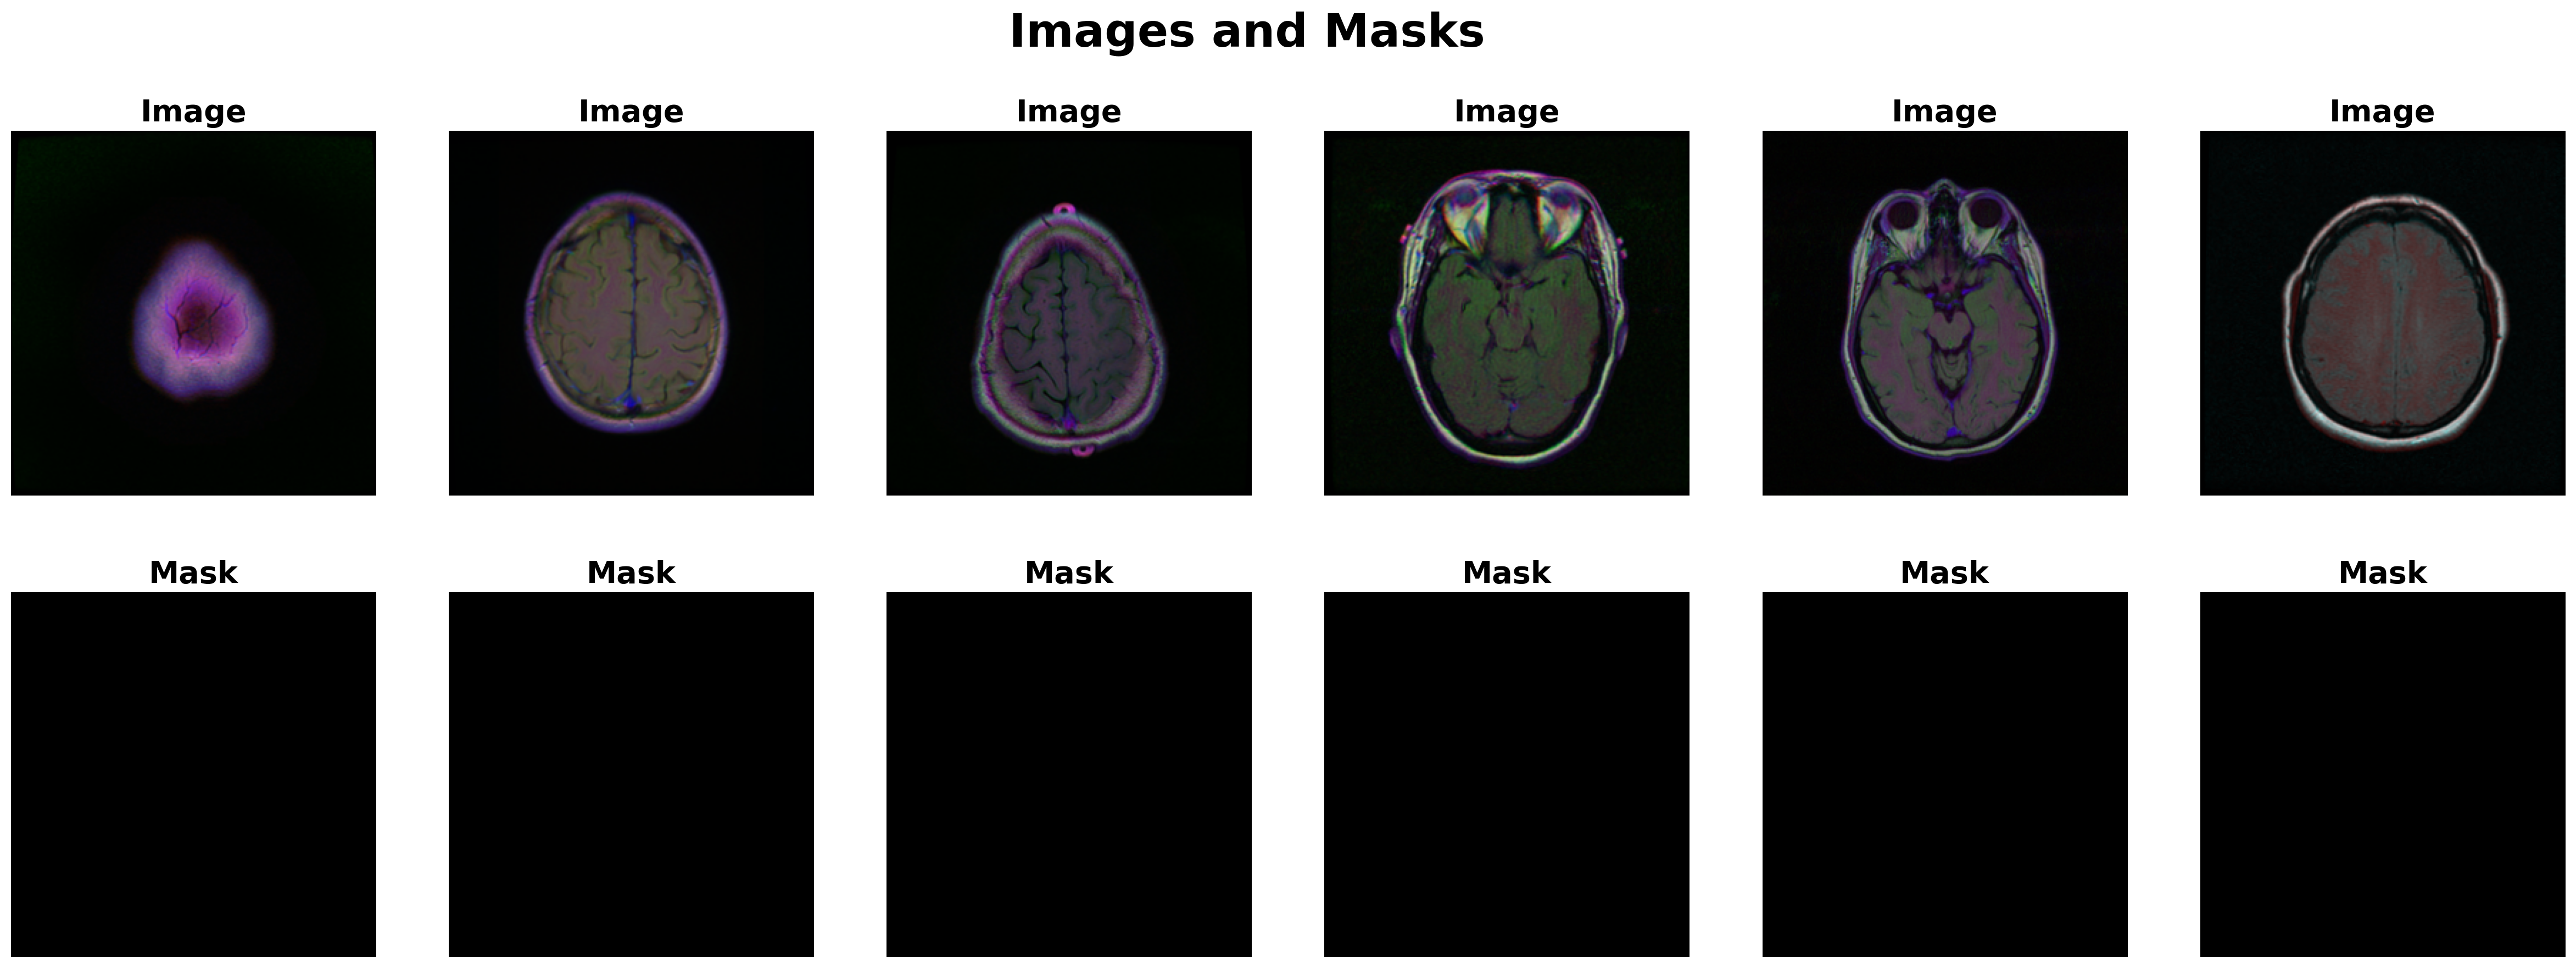

In [6]:
#Bu kod, tanısı negatif olan (yani maskede anormallik olmayan) ilk 6 görüntü ve maskeyi çizmek için kullanılıyor
plot_images_and_masks(train_df[train_df['Diagnosis'] == 0]['Image'].values[:6],
                      train_df[train_df['Diagnosis'] == 0]['Mask'].values[:6])

In [7]:
def plot_class_distribution(train_df, val_df, test_df):
    # Her veri setindeki tanı sütununa göre sınıf dağılımını sayar
    class_distribution_df1 = train_df['Diagnosis'].value_counts()
    class_distribution_df2 = val_df['Diagnosis'].value_counts()
    class_distribution_df3 = test_df['Diagnosis'].value_counts()
    
    # Sınıfların renkleri: mavi (negatif) ve kırmızı (pozitif)
    colors = ['#0504AA', '#ED0101']

    # Şekli tanımlar
    fig = go.Figure()

    # Her sınıf için çubukları ekler
    for class_label in class_distribution_df1.index:
        # Her sınıfın adını belirler (1: Pozitif, 0: Negatif)
        class_name = 'Positive' if class_label == 1 else 'Negative'
        
        # Her sınıf için yığılmış çubuk oluşturur
        fig.add_trace(go.Bar(
            x=['Training', 'Validation', 'Test'],  # X ekseninde veri kümeleri
            y=[class_distribution_df1.get(class_label, 0),  # Eğitim seti için sınıf sayısı
               class_distribution_df2.get(class_label, 0),  # Doğrulama seti için sınıf sayısı
               class_distribution_df3.get(class_label, 0)], # Test seti için sınıf sayısı
            name=f'{class_name}',  # Çubuğun ismi (Pozitif/Negatif)
            marker=dict(color=colors[class_label]),  # Renk ayarı
            opacity=0.75,  # Opaklık ayarı
            width=0.3  # Çubuk genişliği
        ))
    
    # Grafiğin yerleşimini günceller
    fig.update_layout(
        height=700,  # Grafik yüksekliği
        width=800,   # Grafik genişliği
        title_text="Class Distribution",  # Grafik başlığı
        title_font=dict(size=25, family='Balto'),  # Başlık yazı tipi ayarı
        title_x=0.5,  # Başlığı ortalar
        title_y=0.98,  # Başlık pozisyonu
        xaxis=dict(title='Dataframes', title_font=dict(family='Balto', size=19), tickfont=dict(family='Balto', size=19)),  # X ekseni başlığı ve yazı tipi
        yaxis=dict(title='Count', title_font=dict(family='Balto', size=19), tickfont=dict(family='Balto', size=19)),  # Y ekseni başlığı ve yazı tipi
        margin=dict(l=60, r=20, t=50, b=40),  # Kenar boşlukları
        legend=dict(x=0.73, y=0.98, traceorder='normal', orientation='h', font=dict(family='Balto')),  # Lejantın konumu
        barmode='stack'  # Çubukların yığılmış şekilde görüntülenmesi
                )
    
    # Grafiği gösterir
    fig.show()

# Eğitim, doğrulama ve test veri kümelerinde sınıf dağılımını çizdirir
plot_class_distribution(train_df, val_df, test_df)


In [8]:
# Görüntüyü işler
def decode_and_resize_image(img_path):
    # '.tiff' formatındaki görüntüyü okur
    img = tf.io.read_file(img_path)
    with tf.io.gfile.GFile(img_path, 'rb') as f:
        img = Image.open(f)
        img = np.array(img)
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    img = tf.image.resize(img, IMAGE_SIZE, preserve_aspect_ratio=True)
    
    # Görüntüyü [0, 1] aralığına normalize eder
    img = img / 255.0
    
    # Veri yükleme işlemini takip eden bir ilerleme çubuğunu (pbar) günceller
    try:
        pbar.update(1)
    except:
        pass
    
    return img
"""
.tiff formatındaki görüntüyü belirtilen dosya yolundan okur.
img değişkeni, okunmuş görüntü olarak numpy dizisine çevrilir ve tensöre dönüştürülür.
tf.image.resize ile görüntü belirtilen boyuta yeniden boyutlandırılır (IMAGE_SIZE).
Görüntüyü [0, 1] aralığında normalize eder, böylece tüm pikseller 0 ile 1 arasında bir değere sahip olur.
Veri hazırlama işlemini izleyen bir ilerleme çubuğu (pbar) varsa 1 birim ilerletilir.
"""
# Maskeyi işler
def decode_and_resize_mask(mask_path):
    # '.tiff' formatındaki maskeyi okur
    mask = tf.io.read_file(mask_path)
    with tf.io.gfile.GFile(mask_path, 'rb') as f:
        mask = Image.open(f)
        mask = np.array(mask)
    mask = tf.convert_to_tensor(mask, dtype=tf.float32)
    mask = np.expand_dims(mask, axis=-1)
    mask = tf.image.resize(mask, IMAGE_SIZE, method='nearest', preserve_aspect_ratio=True)
    grayscale_mask = tf.reduce_mean(mask, axis=-1, keepdims=True)
    
    # Maskeyi [0, 1] aralığına normalize eder
    grayscale_mask = grayscale_mask / 255.0
    
    # Veri yükleme işlemini takip eden ilerleme çubuğunu (pbar) günceller
    try:
        pbar.update(1)
    except:
        pass
    
    return grayscale_mask
"""
.tiff formatındaki maske dosyasını okur ve numpy dizisine çevirir.
Maske tensöre dönüştürülür (tf.float32 olarak).
Maske, derinlik boyutu eklenerek genişletilir (axis=-1).
tf.image.resize ile boyutu değiştirilir ve "nearest" yöntemi kullanılarak yeniden boyutlandırılır.
Maskedeki gri tonları tek bir kanal halinde ortalanır ve normalize edilir.
İlerleme çubuğu varsa 1 birim ilerletilir.
"""

'\n.tiff formatındaki maske dosyasını okur ve numpy dizisine çevirir.\nMaske tensöre dönüştürülür (tf.float32 olarak).\nMaske, derinlik boyutu eklenerek genişletilir (axis=-1).\ntf.image.resize ile boyutu değiştirilir ve "nearest" yöntemi kullanılarak yeniden boyutlandırılır.\nMaskedeki gri tonları tek bir kanal halinde ortalanır ve normalize edilir.\nİlerleme çubuğu varsa 1 birim ilerletilir.\n'

In [9]:
def processed_input(img, mask):
    # İşlenmiş görüntüler: (None, 256, 256, 3), İşlenmiş maskeler: (None, 256, 256, 1)
    return img, mask

# Veri setini hazırlar
def make_dataset(images, masks):
    dataset = tf.data.Dataset.from_tensor_slices((list(map(lambda x: decode_and_resize_image(x), images)),
                                                 list(map(lambda x: decode_and_resize_mask(x), masks))))
    # Veri setini karıştırır
    dataset = dataset.shuffle(BATCH_SIZE * 8)
    # Veri setine map fonksiyonunu uygular
    dataset = dataset.map(processed_input, num_parallel_calls=tf.data.AUTOTUNE)
    # Şu anki veri grubunu işlerken, bir sonraki veri grubunu belleğe yükleyerek performansı artırır
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

# İşlemi gözlemlemek için ilerleme çubuğu tanımlanır.
pbar = tqdm(total=(len(train_df)+len(val_df))*2, position=0, leave=True, colour='green')

# Maskelere ve görüntülere karşılık gelen listeleri sağlayarak veri setlerini oluşturur.
train_dataset = make_dataset(list(train_df['Image'].values), list(train_df['Mask'].values))
validation_dataset = make_dataset(list(val_df['Image'].values), list(val_df['Mask'].values))

pbar.close()


  0%|          | 0/7678 [00:00<?, ?it/s]

In [10]:
# U-Net Modelinin Tanımlanması

"""

1. **Kodlayıcı (Encoder) Bölümü**:  
   - Modelin kodlayıcı kısmı 4 konvolüsyonel bloktan oluşur. 
   - Her blokta sırasıyla Conv2D katmanları (konvolüsyonel katmanlar), Batch Normalization (veri dağılımını normalize eden katman), Leaky ReLU aktivasyon fonksiyonu ve Max Pooling 2D işlemi (boyutları küçülten bir havuzlama işlemi) kullanılır.
   - Bu katmanlar, modelin düşük çözünürlüklü özellikleri öğrenmesini sağlar.

2. **Köprü (Bridge) Katmanı**:  
   - Kodlayıcı ve kod çözme (decoder) kısmı arasında bir köprü görevi görür.
   - Bu köprü, kodlayıcı ve kod çözücü arasındaki bilgiyi taşır ve aynı zamanda modelin konvolüsyonel özellikleri en yüksek boyutta öğrenmesini sağlar.
   - Conv2D katmanları, Batch Normalization ve Leaky ReLU aktivasyonları kullanılarak bilgi akışı sağlanır.

3. **Kod Çözücü (Decoder) Bölümü**:  
   - Modelin kod çözücü kısmında 4 tane yukarı örnekleme bloğu (upsampling block) bulunur.
   - Bu bloklarda, Conv2DTranspose katmanları (yukarı örnekleme sağlayan konvolüsyon katmanları) kullanılarak görüntü boyutları geri kazanılır.
   - Aynı zamanda, rezidüel bağlantılar (concatenation ile yapılan bağlantılar) sayesinde, kodlayıcıdaki yüksek çözünürlüklü özellikler kod çözücüye eklenir. Bu, modelin daha iyi detaylar öğrenmesini sağlar.

4. **Çıkış Bölümü**:
   - Çıkış katmanı, bir Conv2D katmanı, ardından Batch Normalization ve Leaky ReLU aktivasyonu içerir.
   - Son olarak, bir Conv2D katmanı daha uygulanarak modelin çıktısı alınır.
   - Bu çıkış, segmentasyon sonucunu yani beyin tümörünün maskesini elde etmek için kullanılır.

5. **Hiperparametre Ayarları**:
   - Modeli eğitirken öğrenme hızı (`learning rate`) ve kayıp fonksiyonu (`loss function`) gibi hiperparametreler farklı denemelerle ayarlandı.
   - Sonuç olarak, `0.0003` öğrenme hızı ve ortalama kare hatası (mean squared error) kayıp fonksiyonu bu projede en iyi performansı verdi.
   - Genellikle IoU hatası ve ikili çapraz entropi bu tür projelerde önerilse de, bu projede ortalama kare hatası daha iyi sonuçlar verdi.

"""

'\n\n1. **Kodlayıcı (Encoder) Bölümü**:  \n   - Modelin kodlayıcı kısmı 4 konvolüsyonel bloktan oluşur. \n   - Her blokta sırasıyla Conv2D katmanları (konvolüsyonel katmanlar), Batch Normalization (veri dağılımını normalize eden katman), Leaky ReLU aktivasyon fonksiyonu ve Max Pooling 2D işlemi (boyutları küçülten bir havuzlama işlemi) kullanılır.\n   - Bu katmanlar, modelin düşük çözünürlüklü özellikleri öğrenmesini sağlar.\n\n2. **Köprü (Bridge) Katmanı**:  \n   - Kodlayıcı ve kod çözme (decoder) kısmı arasında bir köprü görevi görür.\n   - Bu köprü, kodlayıcı ve kod çözücü arasındaki bilgiyi taşır ve aynı zamanda modelin konvolüsyonel özellikleri en yüksek boyutta öğrenmesini sağlar.\n   - Conv2D katmanları, Batch Normalization ve Leaky ReLU aktivasyonları kullanılarak bilgi akışı sağlanır.\n\n3. **Kod Çözücü (Decoder) Bölümü**:  \n   - Modelin kod çözücü kısmında 4 tane yukarı örnekleme bloğu (upsampling block) bulunur.\n   - Bu bloklarda, Conv2DTranspose katmanları (yukarı örnekle

In [11]:
# Konvolüsyonel blok
def conv_block(inputs, n_filters, max_pool=True):
    # İlk konvolüsyonel katman: Belirtilen sayıda filtre ile konvolüsyon işlemi yapılır
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal', use_bias=False)(inputs)
    x = BatchNormalization()(x)  # Normalizasyon işlemi yapılır
    x = LeakyReLU(0.2)(x)        # Leaky ReLU aktivasyonu uygulanır
    # İkinci konvolüsyonel katman: Aynı işlemler tekrarlanır
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)
    skip = x                      # Atlama bağlantısı için özellik haritası tutulur
    # Max Pooling işlemi uygulanırsa: Katmanda küçültme yapılır
    if max_pool:
        next_layer = MaxPool2D()(x)
    else:
        next_layer = x
    return next_layer, skip       # Sonraki katman ve atlama bağlantısı döndürülür

# Yukarı örnekleme bloğu
def up_block(reg_inputs, skip_inputs, n_filters):
    # Konvolüsyonel Transpoz (Yukarı örnekleme): Belirtilen filtre sayısı ile yukarı örnekleme yapılır
    x = Conv2DTranspose(n_filters, 3, 2, padding='same')(reg_inputs)
    x = concatenate([x, skip_inputs], axis=3)  # Atlama bağlantısı birleştirilir
    x = conv_block(x, n_filters, max_pool=False)[0]  # Konvolüsyonel blok uygulanır
    return x

# U-Net modeli
def unet(input_size=(256, 256, 3)):
    # Kodlayıcı bloğu
    inputs = Input(shape=input_size, name='Input')
    cb1, cb1_skip = conv_block(inputs, 32)       # İlk konvolüsyonel blok
    cb2, cb2_skip = conv_block(cb1, 64)          # İkinci konvolüsyonel blok
    cb3, cb3_skip = conv_block(cb2, 128)         # Üçüncü konvolüsyonel blok
    cb4, cb4_skip = conv_block(cb3, 256)         # Dördüncü konvolüsyonel blok
    cb5 = conv_block(cb4, 512, max_pool=False)   # Kodlayıcı ile kod çözücü arasında köprü

    # Kod çözücü bloğu
    up1 = up_block(cb5[0], cb4_skip, 256)        # İlk yukarı örnekleme bloğu
    up2 = up_block(up1, cb3_skip, 128)           # İkinci yukarı örnekleme bloğu
    up3 = up_block(up2, cb2_skip, 64)            # Üçüncü yukarı örnekleme bloğu
    up4 = up_block(up3, cb1_skip, 32)            # Dördüncü yukarı örnekleme bloğu

    # Çıkış bloğu
    conv1 = Conv2D(32, 3, padding='same', kernel_initializer='he_normal', use_bias=False)(up4)
    bn = BatchNormalization()(conv1)
    act = LeakyReLU(0.2)(bn)
    outputs = Conv2D(1, 1, padding='same', activation='sigmoid', name='Output')(act)  # Segmentasyon için çıkış katmanı

    # Model oluşturuluyor
    unet = Model(inputs=inputs, outputs=outputs)

    # Model derleniyor
    unet.compile(optimizer=keras.optimizers.Adam(3e-4), loss='mean_squared_error')  # Hata fonksiyonu: ortalama kare hata

    return unet

# Model oluşturuluyor
model = unet()

# Modeli çizerek gösterme
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, dpi=60)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [ ]:
# Path to save the best weights
checkpoint_path = "best_model.weights.h5"

# Defining ModelCheckpoint callback to save the best weights
checkpoint_callback = ModelCheckpoint(filepath=checkpoint_path,
                                      monitor='val_loss',
                                      save_best_only=True,
                                      save_weights_only=True,
                                      verbose=1)

# Defining EarlyStopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# Training the model
history = model.fit(train_dataset, validation_data=validation_dataset,
                    epochs=EPOCHS, callbacks=[early_stopping, checkpoint_callback])

# Loading the best weights
model.load_weights("best_model.weights.h5")

Epoch 1/60


In [ ]:
def plot_history(history):
    plots = go.Figure([go.Scatter(x=[x+1 for x in range(EPOCHS)], y=history.history['loss'],
                                  name='Training Loss',mode='lines+markers',
                                  marker=dict(color='#00008B'),line=dict(width=1),showlegend=True),

                       go.Scatter(x=[x+1 for x in range(EPOCHS)], y=history.history['val_loss'],
                                  name='Validation Loss',mode='lines+markers',
                                  marker=dict(color="#004EFF"),line=dict(width=1),showlegend=True)])

    plots.update_layout(
        title_text="Training vs Validation",
        title_font=dict(size=25, family='Balto'),
        title_x=0.5,
        title_y=0.98,
        xaxis=dict(title='Epoch', title_font=dict(family='Balto', size=19), tickfont=dict(family='Balto', size=19)),
        yaxis=dict(title='Loss', title_font=dict(family='Balto', size=19), tickfont=dict(family='Balto', size=19)),
        margin=dict(l=60, r=20, t=50, b=40),
        legend=dict(x=0.75, y=0.98, traceorder='normal', orientation='h', font=dict(family='Balto'))  # Placing legend inside
    )

    plots.show()
    
plot_history(history)

In [ ]:
# Calculates IoU
def IoU(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) - intersection
    IoU = (intersection + 1e-25) / (union + 1e-25)  # Adding a small epsilon to avoid division by zero
    return IoU

# Returns a dataframe containing the IDs, the actual diagnoses, the predicted diagnoses, and IoU for each prediction,
# along with a dictionary of masks associated with each ID.
def predictions(df, threshold=0.5):
    x = np.array(list(map(lambda v: decode_and_resize_image(v), df['Image'])))
    y = np.array(list(map(lambda v: decode_and_resize_mask(v), df['Mask'])))
    
    # Predicting the masks
    pred = model.predict(x)
    
    # Thresholding predicted mask values
    pred_thresholded = tf.cast(pred > threshold, dtype=tf.float32)
    
    # Getting each mask's IoU
    IoUs = IoU(y, pred_thresholded).numpy()
    IoUs = list(map(lambda x: round(x, 3), IoUs))
    
    # Takes the largest pixel
    largest_pixel = lambda y_: np.max(y_)
    
    # Determines if the predicted mask contains an abnormality or not (+ or -)
    # Remember that a negative image's mask is just an entirely black image.
    diagnotic_function = lambda z: 1 if largest_pixel(z) > 0 else 0
    
    # Storing the predicted diagnosis corresponding to each image
    diagnoses = list(map(lambda x: diagnotic_function(x), pred_thresholded))
    
    # Prediction dataframe (Diagnoses and IoUs)
    prediction_df = pd.DataFrame({'ID': df['ID'].values, 'Actual Diagnosis': df['Diagnosis'].values,
                                  'Predicted Diagnosis': diagnoses, 'IoU': list(IoUs)})
    
    # Prediction dictionary (ID: array of mask values)
    prediction_dict = {}
    for i, j in zip(df['ID'].values, pred_thresholded):
        prediction_dict[i] = j
    
    return prediction_dict, prediction_df

# Making predictions
prediction, prediction_df = predictions(test_df)

print(len(prediction), list(prediction.values())[0].shape)

prediction_df.head()

In [ ]:
prediction_df.describe()

In [ ]:
# IDs for 24 Positive Diagnoses
positive_ids = list(test_df[test_df['Diagnosis'] == 1]['ID'][:24].values)
# IDs for 24 Negative Diagnoses
negative_ids = list(test_df[test_df['Diagnosis'] == 0]['ID'][:24].values)

In [ ]:
plot_images_and_masks([test_df.loc[test_df['ID'] == ID, 'Image'].values[0] for ID in positive_ids[:8]],
                      [test_df.loc[test_df['ID'] == ID, 'Mask'].values[0] for ID in positive_ids[:8]],
                      [prediction[ID].numpy() for ID in positive_ids[:8]],
                     [prediction_df.loc[prediction_df['ID'] == ID, 'IoU'].values[0] for ID in positive_ids[:8]])

In [ ]:
plot_images_and_masks([test_df.loc[test_df['ID'] == ID, 'Image'].values[0] for ID in positive_ids[8:16]],
                      [test_df.loc[test_df['ID'] == ID, 'Mask'].values[0] for ID in positive_ids[8:16]],
                      [prediction[ID].numpy() for ID in positive_ids[8:16]],
                     [prediction_df.loc[prediction_df['ID'] == ID, 'IoU'].values[0] for ID in positive_ids[8:16]])

In [ ]:
plot_images_and_masks([test_df.loc[test_df['ID'] == ID, 'Image'].values[0] for ID in positive_ids[16:]],
                      [test_df.loc[test_df['ID'] == ID, 'Mask'].values[0] for ID in positive_ids[16:]],
                      [prediction[ID].numpy() for ID in positive_ids[16:]],
                     [prediction_df.loc[prediction_df['ID'] == ID, 'IoU'].values[0] for ID in positive_ids[16:]])

In [ ]:
plot_images_and_masks([test_df.loc[test_df['ID'] == ID, 'Image'].values[0] for ID in negative_ids[:8]],
                      [test_df.loc[test_df['ID'] == ID, 'Mask'].values[0] for ID in negative_ids[:8]],
                      [prediction[ID].numpy() for ID in negative_ids[:8]],
                     [prediction_df.loc[prediction_df['ID'] == ID, 'IoU'].values[0] for ID in negative_ids[:8]])

In [ ]:
plot_images_and_masks([test_df.loc[test_df['ID'] == ID, 'Image'].values[0] for ID in negative_ids[8:16]],
                      [test_df.loc[test_df['ID'] == ID, 'Mask'].values[0] for ID in negative_ids[8:16]],
                      [prediction[ID].numpy() for ID in negative_ids[8:16]],
                     [prediction_df.loc[prediction_df['ID'] == ID, 'IoU'].values[0] for ID in negative_ids[8:16]])

In [ ]:
plot_images_and_masks([test_df.loc[test_df['ID'] == ID, 'Image'].values[0] for ID in negative_ids[16:]],
                      [test_df.loc[test_df['ID'] == ID, 'Mask'].values[0] for ID in negative_ids[16:]],
                      [prediction[ID].numpy() for ID in negative_ids[16:]],
                     [prediction_df.loc[prediction_df['ID'] == ID, 'IoU'].values[0] for ID in negative_ids[16:]])

In [ ]:
# Making predictions
prediction, prediction_df = predictions(pd.concat([test_df, val_df], ignore_index=True))

print(len(prediction), list(prediction.values())[0].shape)

prediction_df.head()

In [ ]:
prediction_df.describe()

In [ ]:
def plot_class_distribution(df):
    # Counting the actual and predicted class distributions (+, -).
    class_distribution_df1 = df['Actual Diagnosis'].value_counts()
    class_distribution_df2 = df['Predicted Diagnosis'].value_counts()
    mean_IoU = round(df['IoU'].mean(), 3)
    
    colors = ['#0504AA', '#ED0101']

    # Defining figure
    fig = go.Figure()

    # Adding bars for each dataframe and each class
    for class_label in class_distribution_df1.index:
        # Getting the name of each class (+ or -)
        class_name = 'Positive' if class_label == 1 else 'Negative'
        
        # Creating stacked bar for each class
        fig.add_trace(go.Bar(
            x=['Actual', 'Predicted'],
            y=[class_distribution_df1.get(class_label, 0),
               class_distribution_df2.get(class_label, 0)],
            
            name=f'{class_name}',
            marker=dict(color=colors[class_label]),
            opacity=0.75,
            width=0.25
        ))
    
    # Updating layout
    fig.update_layout(
        height=700,
        width=800,
        title_text=f"Class Distribution | IoU {round(float(mean_IoU), 4)}",
        title_font=dict(size=25, family='Balto'),
        title_x=0.5,
        title_y=0.98,
        xaxis=dict(title='Columns', title_font=dict(family='Balto', size=19), tickfont=dict(family='Balto', size=19)),
        yaxis=dict(title='Count', title_font=dict(family='Balto', size=19), tickfont=dict(family='Balto', size=19)),
        margin=dict(l=60, r=20, t=50, b=40), 
        legend=dict(x=0.38, y=0.98, traceorder='normal', orientation='h', font=dict(family='Balto')),  # Placing legend inside
        barmode='stack'  # Setting barmode to 'stack' to stack the bars
                )
    # Showing the figure
    fig.show()
    
plot_class_distribution(prediction_df)

In [ ]:
# Plots Confusion Matrix
def Confusion_Matrix(df):
    confusionMatrix = confusion_matrix(df['Actual Diagnosis'], df['Predicted Diagnosis'])

    # Defining class names
    class_names = ['Negative', 'Positive']

    # Normalizing confusion matrix
    confusionMatrixNormalized = confusionMatrix.astype('float') / confusionMatrix.sum(axis=1)[:, np.newaxis]

    # Creating heatmap trace for confusion matrix
    heatmap_trace = go.Heatmap(z=confusionMatrixNormalized,
                               x=class_names,
                               y=class_names,
                               colorscale='Viridis',
                               colorbar=dict(title='Proportion', title_font=dict(family='Balto'),
                                             tickfont=dict(family='Balto'), tickformat='.2f'))

    # Creating text annotations for each cell in the heatmap
    annotations = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            annotations.append(dict(text=str(confusionMatrix[i, j]),
                                    x=class_names[j],
                                    y=class_names[i],
                                    showarrow=False,
                                    font=dict(color='black', family='Balto', size=25)))

    # Creating layout
    layout = go.Layout(height=700,
                       width=800,
                       title='Confusion Matrix',
                       title_font=dict(size=25, family='Balto'),
                       title_x=0.5,
                       title_y=0.95,
                       xaxis=dict(title='Predicted label', title_font=dict(family='Balto', size=19), tickfont=dict(family='Balto', size=19)),
                       yaxis=dict(title='True label', title_font=dict(family='Balto', size=19), tickfont=dict(family='Balto', size=19)),
                       annotations=annotations)

    # Creating figure
    fig = go.Figure(data=[heatmap_trace], layout=layout)

    # Showing the plot
    fig.show()
    
Confusion_Matrix(prediction_df)

In [ ]:
# Rounds the number of Classification Report output
def round_dict(d, decimals=2):
    if isinstance(d, dict):
        return {key: round_dict(value, decimals) for key, value in d.items()}
    else:
        return round(d, decimals)

# Plots Classification Report
def Classification_Report(df):
    clf_report = classification_report(df['Actual Diagnosis'],
                                       df['Predicted Diagnosis'],
                                       labels=np.arange(2),
                                       target_names=['Negative', 'Positive'],
                                       output_dict=True)

    rounded_data = round_dict(clf_report, decimals=2)

    # Converting classification report data to dataframe
    df_clf_report = pd.DataFrame.from_dict(rounded_data)

    # Transposing dataframe for proper visualization
    df_clf_report = df_clf_report.T

    # Reversing the order of rows in the dataframe
    df_clf_report = df_clf_report.iloc[::-1]

    # Creating heatmap trace for classification report
    heatmap_trace = go.Heatmap(z=df_clf_report.values[:, :-1],  # Excluding 'support' column
                               x=df_clf_report.columns[:-1],  # Excluding 'support' column
                               y=df_clf_report.index,
                               colorscale='Viridis')

    # Creating text annotations for each cell in the heatmap
    annotations = []
    for i in range(len(df_clf_report.index)):
        for j in range(len(df_clf_report.columns) - 1):
            annotations.append(dict(text=str(df_clf_report.values[i, j]),
                                    x=df_clf_report.columns[j],
                                    y=df_clf_report.index[i],
                                    showarrow=False,
                                    font=dict(color='black', family='Balto', size=22)))

    # Creating layout
    layout = go.Layout(height=800,
                       width=800,
                       title='Classification Report',
                       title_font=dict(size=25, family='Balto'),
                       title_x=0.5,
                       title_y=0.95,
                       xaxis=dict(title='Metrics', title_font=dict(family='Balto', size=19), tickfont=dict(family='Balto', size=19)),
                       yaxis=dict(title='Class', title_font=dict(family='Balto', size=19), tickfont=dict(family='Balto', size=19)),
                       annotations=annotations)

    # Creating figure
    fig = go.Figure(data=[heatmap_trace], layout=layout)

    # Showing the plot
    fig.show()
    
Classification_Report(prediction_df)